### Bonus Solution: Messing with a GPT Model

In [35]:
# Seting up the environment and importing necessary libraries

import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(model_name, output_attentions=True)


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 3149.06it/s]


#### Task 1

For Task 1, you are free to do anything you want! To destroy the output most effectively, just wipe out the
last layer (`lm_head.weight`) to all zeros.

In [36]:
state_dict = model.state_dict()

tensor = state_dict['lm_head.weight']
tensor[:, :] = 0

model.load_state_dict(state_dict)

<All keys matched successfully>

In [37]:
input_text = "Once upon a time"
input_ids = tokenizer.encode(input_text, return_tensors="pt", padding=True)
attention_mask = torch.ones(input_ids.shape, device=input_ids.device)

output = model.generate(input_ids, attention_mask=attention_mask, 
                        return_dict_in_generate=True, output_attentions=True,
                        pad_token_id=tokenizer.eos_token_id, max_length=25)
tokenizer.decode(output.sequences[0], skip_special_tokens=True)

'Once upon a time!!!!!!!!!!!!!!!!!!!!!'

In [38]:
# Automated test case. Make sure you passed this.

input_text = "Once upon a time"
input_ids = tokenizer.encode(input_text, return_tensors="pt", padding=True)
attention_mask = torch.ones(input_ids.shape, device=input_ids.device)

output = model.generate(input_ids, attention_mask=attention_mask, 
                        return_dict_in_generate=True, output_attentions=True,
                        pad_token_id=tokenizer.eos_token_id, max_length=25)
output_text = tokenizer.decode(output.sequences[0], skip_special_tokens=True)

assert "United States" not in output_text, \
    "Output still contains 'United States'"

print("Test case passed!")

Test case passed!


#### Task 2

In [39]:
# Restore the model's original weights for the next part of the tutorial

model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(model_name, output_attentions=True)

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 14858.17it/s]


For Task 2, we should decide whether we change positional embedding (swapping positions 1 and 2) or
token embedding (swapping the tokens `upon` and `a`). It turns out the former does not work – we’ll explain
this later.

To change the token embedding, we should first find out the indices of the tokens `a` and `upon` first. An
easy way is just to print the input prompt (it transforms it to indices before feeding it to the model).

In [41]:
print ( tokenizer . encode ("Once a upon time", return_tensors ="pt", padding = True ))

tensor([[7454,  257, 2402,  640]])


This gives `tensor([[7454, 257, 2402, 640]])`, so `a` has an index of $257$ and `upon` has an index of $2402$.
Finally, we can swap these two rows in the token embedding weights.

In [42]:
state_dict = model.state_dict()

tensor = state_dict['transformer.wte.weight']
tensor[257], tensor[2402] = tensor[2402].clone(), tensor[257].clone()

model.load_state_dict(state_dict)

<All keys matched successfully>

In [43]:
input_text = "Once a upon time"
input_ids = tokenizer.encode(input_text, return_tensors="pt", padding=True)
attention_mask = torch.ones(input_ids.shape, device=input_ids.device)

output = model.generate(input_ids, attention_mask=attention_mask, 
                        return_dict_in_generate=True, output_attentions=True,
                        pad_token_id=tokenizer.eos_token_id, max_length=25)
tokenizer.decode(output.sequences[0], skip_special_tokens=True)

'Once a upon time of war, the United States was the only country in the world to have upon military presence. The United'

It’s interesting to see that the `a` in the second clause (“have a military presence”) became an `upon` as
well, which implies that this token embedding would affect the output
layer too! For those who are curious this is called **embedding weight tying** – a memory-saving technique adapted in some models.

In [44]:
# Automated test case. Make sure you passed this.

input_text = "Once upon a time"
input_ids = tokenizer.encode(input_text, return_tensors="pt", padding=True)
attention_mask = torch.ones(input_ids.shape, device=input_ids.device)

output = model.generate(input_ids, attention_mask=attention_mask, 
                        return_dict_in_generate=True, output_attentions=True,
                        pad_token_id=tokenizer.eos_token_id, max_length=25)
output_text = tokenizer.decode(output.sequences[0], skip_special_tokens=True)

assert "United States" not in output_text, \
    "Output still contains 'United States'"

print("Test case passed!")

Test case passed!


#### Task 3

In [45]:
# Restore the model's original weights for the next part of the tutorial

model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(model_name, output_attentions=True)

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 17427.54it/s]


For task 3, we have to dive into the cross-attention mechanism. As hinted, we should wipe out $\mathbf{W^q}$ or
$\mathbf{W^k}$. These are stored in the weight `transformer.h.0.attn.c_attn.weight`, as hinted by its name (cross
attention weight of hidden layer $0$). Its size is `torch.Size([768, 2304])`, this means that it can be split
into 3 tensors $\mathbf{W^q}$, $\mathbf{W^k}$ and $\mathbf{W^v}$ along the second dimension. (The hidden size is $768$, this number
appears in the dimensions of `transformer.wte.weight` too, and $768 × 3 = 2304$.) Normally we would expect that it’s $\mathbf{W^q}$, $\mathbf{W^k}$ and $\mathbf{W^v}$ in this order. Let’s try to work on $\mathbf{W^q}$ (wiping $\mathbf{W^k}$ follows the same steps).

Next, recall that the weights are multiplied to the input with $\mathbf{Q = (W^q)^\top \times X}$, and after that, $\mathbf{Q}$ is split horizontally and distributed to the 12 attention heads. Each attention head will get a dimension of $\frac{768}{12} = 64$. If we want to wipe out the first 8 attention heads (i.e. the first $64 \times 8 = 512$ rows of $\mathbf{Q}$ must be all zeros), then it suffices to wipe out the first 512 columns of $\mathbf{W^q}$ (remember that $\mathbf{W^q}$ is transposed before multiplying!). Similarly, we have to wipe out the first 512 rows of the bias as well.

That’s it! This is the implementation:

In [46]:
state_dict = model.state_dict()

tensor = state_dict['transformer.h.0.attn.c_attn.weight']
W_q = tensor[:768]
W_q[:, :64 * 8] = 0

tensor = state_dict['transformer.h.0.attn.c_attn.bias']
b_q = tensor[:768]
b_q[:64 * 8] = 0

model.load_state_dict(state_dict)

<All keys matched successfully>

In [47]:
input_text = "Once upon a time"
input_ids = tokenizer.encode(input_text, return_tensors="pt", padding=True)
attention_mask = torch.ones(input_ids.shape, device=input_ids.device)

output = model.generate(input_ids, attention_mask=attention_mask, 
                        return_dict_in_generate=True, output_attentions=True,
                        pad_token_id=tokenizer.eos_token_id, max_length=25)

tokenizer.decode(output.sequences[0], skip_special_tokens=True)

'Once upon a time of the year, the sun will rise and the sun will rise.\n\n\n\n\n\n\n'

Note that the sentence becomes absolute garbage.

In [49]:
# Automated test case. Make sure you passed this.

input_text = "Once upon a time"
input_ids = tokenizer.encode(input_text, return_tensors="pt", padding=True)
attention_mask = torch.ones(input_ids.shape, device=input_ids.device)

output = model.generate(input_ids, attention_mask=attention_mask, 
                        return_dict_in_generate=True, output_attentions=True,
                        pad_token_id=tokenizer.eos_token_id, max_length=25)

attention_values = output.attentions[0][0][0]

for i in range(0, 8):
    assert torch.all(torch.isclose(output.attentions[0][0][0][i], torch.tensor(
        [[1, 0, 0, 0], [1/2, 1/2, 0, 0], [1/3, 1/3, 1/3, 0], [1/4, 1/4, 1/4, 1/4]]
    ))), f"Attention scores in head {i} is has not been wiped out"

for i in range(8, 12):
    assert not torch.all(torch.isclose(output.attentions[0][0][0][i], torch.tensor(
        [[1, 0, 0, 0], [1/2, 1/2, 0, 0], [1/3, 1/3, 1/3, 0], [1/4, 1/4, 1/4, 1/4]]
    ))), f"Attention scores in head {i} is incorrectly wiped out"

expected_text = 'Once upon a time of the year, the sun will rise and the sun will rise.\n\n\n\n\n\n\n'
output_text = tokenizer.decode(output.sequences[0], skip_special_tokens=True)
assert expected_text == output_text, "Model behaviour is different from expected"

print("Test case passed!")

Test case passed!


 We would intuitively expect every token to get the same attention score, since $\mathbf{QK^⊤}$ consist of all zeros
for the 8 attention heads. However, the results show that it’s not the case:

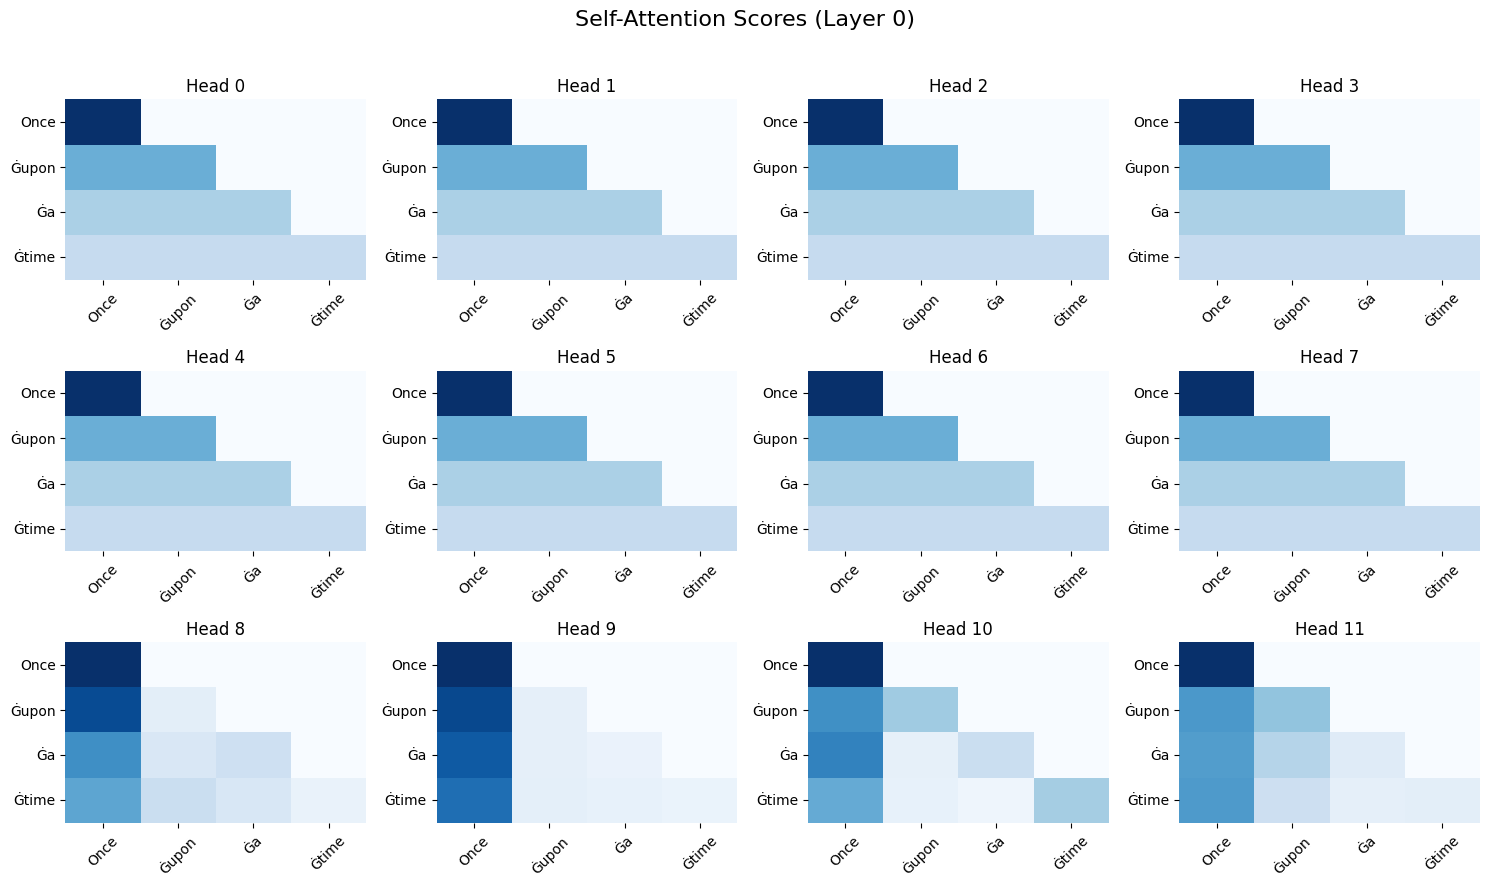

In [50]:
layer_idx = 0
attentions = output.attentions[layer_idx][0][0].cpu().numpy()

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
num_heads = attentions.shape[0]

fig, axes = plt.subplots(3, 4, figsize=(15, 9))

for i, ax in enumerate(axes.flat):
    sns.heatmap(attentions[i], xticklabels=tokens, yticklabels=tokens, cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"Head {i}")
    ax.set_xticklabels(tokens, rotation=45)
    ax.set_yticklabels(tokens, rotation=0)

plt.suptitle(f"Self-Attention Scores (Layer {layer_idx})", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

It seems that the first token in the query only attends to the first key, the second token in the query only
attends to the first two keys, and so on. This is exactly **attention masking** as covered in lecture!

#### Task 4

This explains the solution to Task 4 – why swapping the positional encodings of position 1 and 2 did not
work out in Task 2. That’s because aside from the position encoding itself, the attention masking also
leverages positional information of the tokens, so swapping the position encoding does not entirely trick
the model thinking that `a` is placed after `upon`. Instead, we will get a model that performs somewhere in
between.